In [6]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [5]:
import sys
print(sys.executable)

c:\Users\akash\Downloads\machine learning project\.venv\Scripts\python.exe


Predicting Freight Cost
objective:predict freight cost for vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

Freight is a non-trivial component of landed cost
Poor freight estimates distort margin and inventory planning 
Automation freight estimation helps procurement teams forecast true cost before invoice arrival

In [2]:


# Connect to database
conn = sqlite3.connect("C:/Users/akash/Downloads/inventory.db")

# View all tables
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [3]:
for table in tables['name']:
    print('table',table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

table purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
vendor_df[['Quantity','Dollars','Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


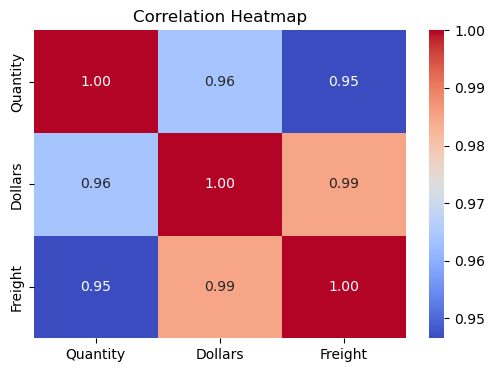

In [6]:
plt.figure(figsize=(6,4))

corr = vendor_df[['Quantity', 'Dollars', 'Freight']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

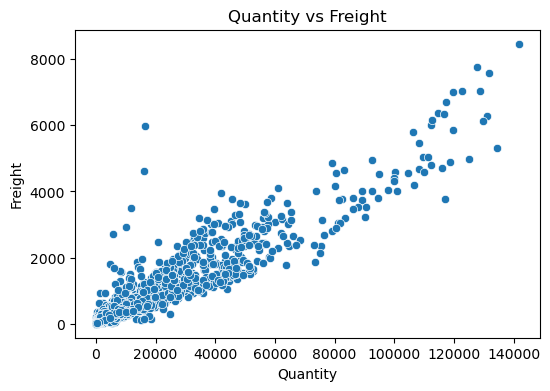

In [7]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=vendor_df,
    x='Quantity',
    y='Freight'
)

plt.title('Quantity vs Freight')
plt.xlabel('Quantity')
plt.ylabel('Freight')

plt.show()

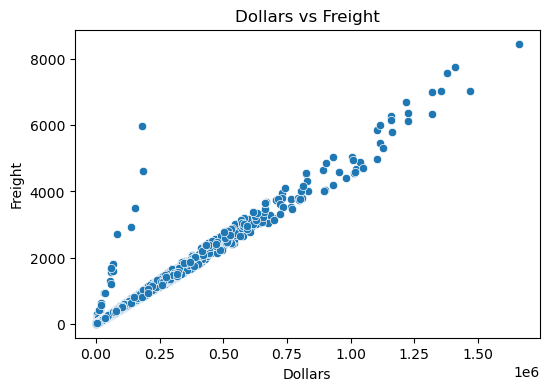

In [8]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=vendor_df,
    x='Dollars',
    y='Freight'
)

plt.title('Dollars vs Freight')
plt.xlabel('Dollars')
plt.ylabel('Freight')

plt.show()

In [9]:
vendor_df['Freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

In [10]:
low_quantity=vendor_df['Quantity'].quantile(0.25)
high_quantity=vendor_df['Quantity'].quantile(0.75)

In [11]:
low_quantity

np.float64(83.0)

In [12]:
high_quantity

np.float64(5100.5)

In [13]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'Freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [14]:
vendor_df.loc[vendor_df['Quantity']<high_quantity,'Freight_per_unit'].mean()

np.float64(0.07463123347873155)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Features and target
X = vendor_df[['Quantity', 'Dollars']]
y = vendor_df['Freight']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=14,random_state=42),
    'Random Forest': RandomForestRegressor(max_depth=7,
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)

print(results_df.sort_values('R2', ascending=False))

               Model        MAE        RMSE        R2
0  Linear Regression  24.459181  124.428785  0.970020
2      Random Forest  26.218017  136.770977  0.963777
1      Decision Tree  34.155379  180.401031  0.936981


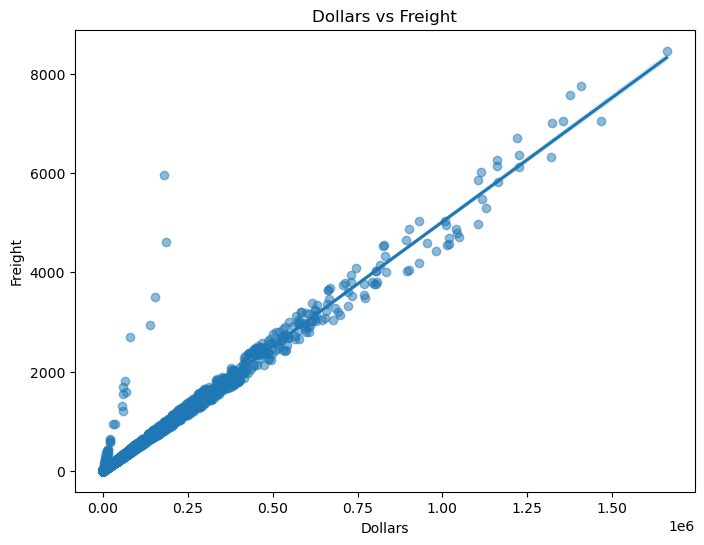

In [29]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=vendor_df,
    x='Dollars',
    y='Freight',
    scatter_kws={'alpha':0.5}
)

plt.title('Dollars vs Freight')
plt.show()

In [31]:
import os

project_path = os.path.abspath("machine learning project")

print(project_path)

C:\Users\akash\machine learning project\notebooks\machine learning project
